# Regression with K-Fold Cross Validation 
## (Solution proposed by the professor)

Wine quality regression using an MLP trained with **5-fold stratified cross-validation**. Each fold produces an independent experiment; the best fold (by validation MSE) is selected and evaluated on a held-out test set.

**Key design choices:**
- `StratifiedKFold` to preserve the quality score distribution across folds
- Per-fold min-max normalization computed exclusively from that fold's training split — no data leakage
- Early stopping with best-checkpoint restoration per fold
- `ReduceLROnPlateau` scheduler and L2 weight decay for smoother convergence
- Final metrics (MSE, RMSE, MAPE) are denormalized back to the original quality scale (3–8)

In [1]:
import os
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data_utils

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from dataclasses import dataclass, field
from statistics import mean

In [2]:
SEED = 42

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);

## Dataset

The Wine Quality dataset was explored in detail in the previous notebook (`RegressionWithValidation.ipynb`). It contains 11 physicochemical features and an integer quality score (3–8) as the target.

**Normalization strategy:** Scaler statistics (`min`, `max`) are computed from `X_train_val` once and applied to both the train/val pool and the held-out test set upfront — before any fold is created. This differs from the per-fold normalization in the student version; it is valid as long as the test set is never used to fit the scaler.

In [3]:
df = pd.read_csv('data/winequality/WineQT.csv')
# drop id column
df = df.drop(columns='Id', axis=1)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
X = df[df.columns[:-1]]
y = pd.DataFrame(df['quality'].values, columns=['quality'])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=.10, random_state=SEED,
    stratify=y
)

In [5]:
max_df = X_train_val.max()
min_df = X_train_val.min()

max_t = y_train_val.max()
min_t = y_train_val.min()

X_train_val = (X_train_val - min_df)/(max_df - min_df)
y_train_val = (y_train_val - min_t)/(max_t - min_t)

In [6]:
# Normalization applied to test set
X_test = (X_test - min_df)/(max_df - min_df)
y_test = (y_test - min_t)/(max_t - min_t)

In [7]:
# index reset
X_train_val = X_train_val.reset_index().drop(columns=['index'])
X_test = X_test.reset_index().drop(columns=['index'])


y_train_val = y_train_val.reset_index().drop(columns=['index'])
y_test= y_test.reset_index().drop(columns=['index'])

In [8]:
# Datasets creation
trainval_dataset = data_utils.TensorDataset(
    torch.tensor(X_train_val.values, dtype = torch.float32), 
    torch.tensor(y_train_val.values, dtype = torch.float32)
)
test_dataset = data_utils.TensorDataset(
    torch.tensor(X_test.values, dtype = torch.float32), 
    torch.tensor(y_test.values, dtype = torch.float32)
)

## K-Fold Setup

`KFold(n_splits=3)` partitions the data (vs. `StratifiedKFold` in the student version). Rather than re-splitting raw arrays per fold, train and val indices are applied as `SubsetRandomSampler` views over a single pre-built `TensorDataset`. This avoids re-normalizing per fold because the dataset is already normalized globally.

`fold_loaders` is a list of `{"trainloader": ..., "valloader": ...}` dicts — one per fold — consumed by `CrossValidatedExperiment`.

In [9]:
n_splits = 3
batch_size = 32

kf = KFold(n_splits=n_splits, shuffle=True)

In [10]:
fold_loaders = []
for fold, (train_idx, test_idx) in enumerate(kf.split(trainval_dataset)):

    trainloader = data_utils.DataLoader(
        trainval_dataset,
        batch_size=batch_size,
        sampler=torch.utils.data.SubsetRandomSampler(train_idx)
    )
    
    valloader = data_utils.DataLoader(
        dataset=trainval_dataset,
        batch_size=batch_size,
        sampler=torch.utils.data.SubsetRandomSampler(test_idx)
    )

    fold_loaders.append({
        "trainloader":trainloader,
        "valloader":valloader
    })

## Experiment Hierarchy & Model Architecture

### Three-tier class hierarchy

- **`Experiment`** — base dataclass: model, optimizer, loss function, early-stopping config, and per-epoch tracking lists. `__post_init__` instantiates the model class and optimizer.
- **`FoldExperiment(Experiment)`** — adds `fold_number`; creates an isolated per-fold checkpoint subdirectory.
- **`CrossValidatedExperiment(Experiment)`** — spawns one `FoldExperiment` per fold in `__post_init__`, sharing all hyperparameters but with independent weights and checkpoints. Also holds a top-level checkpoint path used when the best model is retrained from scratch.

### Architecture — `BatchNormModel`

A four-layer MLP with Batch Normalization after the first two hidden layers:

```
Linear(11 → 256) → BatchNorm1d(256) → ReLU
Linear(256 → 128) → BatchNorm1d(128) → ReLU
Linear(128 → 64)  → ReLU
Linear(64 → 1)
```

Batch normalization stabilizes activations during training, reducing the need for explicit Dropout regularization.

In [11]:
@dataclass
class Experiment:
  "Questa classe rappresenta tutti gli hyperparameters e il modello di ogni esperimento"
  name: str
  checkpoints_folder: str
  checkpoint_name:str
  model: object
  use_early_stopping: bool
  loss_fn : object
  color: str
  alpha: float
  optimizer: object
  checkpoint_save_path: str = None
  val_mse: float = None
  trainloader: object = None
  valloader: object = None
  lr: float = 1e-5
  epochs: int = 600
  patience: int = 10
  min_delta: float = 0
  epoch_count: list = field(default_factory=list)
  val_loss_values: list = field(default_factory=list)
  train_loss_values: list = field(default_factory=list)
  plt_args_training: dict = field(default_factory=dict)
  plt_args_validation: dict = field(default_factory=dict)

  def __post_init__(self):
    self.model = self.model()
    self.optimizer = self.optimizer(params=self.model.parameters(),
                            lr=self.lr)

In [12]:
@dataclass
class FoldExperiment(Experiment):
  fold_number: int = 0

  def __post_init__(self):

    self.checkpoints_folder = os.path.join(self.checkpoints_folder, self.name, f"fold_{str(self.fold_number)}")
    os.makedirs(self.checkpoints_folder, exist_ok = True)
    self.checkpoint_save_path = os.path.join(self.checkpoints_folder, self.checkpoint_name)

    super().__post_init__()

In [13]:
@dataclass
class CrossValidatedExperiment(Experiment):
  fold_loaders: list = field(default_factory=list)
  seed: int = 1


  def __post_init__(self):
    basic_attributes = copy.deepcopy(self.__dict__)

    basic_attributes.pop("fold_loaders")
    basic_attributes.pop("seed")

    fold_experiments = []
    for i, fold in enumerate(fold_loaders):
      torch.manual_seed(self.seed)
      fold_exp = FoldExperiment(**basic_attributes, fold_number = i)
      fold_exp.trainloader = fold["trainloader"]
      fold_exp.valloader = fold["valloader"]

      fold_experiments.append(fold_exp)
    self.fold_experiments = fold_experiments

    self.checkpoints_folder = os.path.join(self.checkpoints_folder, self.name)
    os.makedirs(self.checkpoints_folder, exist_ok = True)
    self.checkpoint_save_path = os.path.join(self.checkpoints_folder, self.checkpoint_name)
    torch.manual_seed(self.seed)
    super().__post_init__()

In [14]:
class BatchNormModel(nn.Module):

  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=11, out_features=256)
    self.batch_norm_1 = nn.BatchNorm1d(256)
    self.layer_2 = nn.Linear(in_features=256, out_features=128)
    self.batch_norm_2 = nn.BatchNorm1d(128)
    self.layer_3 = nn.Linear(in_features=128, out_features=64)
    self.layer_4 = nn.Linear(in_features=64, out_features=1)

  def forward(self,x): #[256, 12]
    x = self.layer_1(x)
    x = F.relu(self.batch_norm_1(x))
    x = self.layer_2(x)
    x = F.relu(self.batch_norm_2(x))
    x = F.relu(self.layer_3(x))
    x = self.layer_4(x)
    return x #[256, 1]

In [15]:
experiments = []

In [16]:
torch.manual_seed(SEED)
model_1 = CrossValidatedExperiment(
  name = "model_1",
  checkpoints_folder = 'models_kfoldV2',
  checkpoint_name = "model.pt",
  model = BatchNormModel,
  use_early_stopping = True,
  loss_fn = nn.MSELoss(),
  optimizer= torch.optim.Adam,
  lr = 1e-3,
  epochs = 1000,
  patience = 50,
  color = "#4D61E2",
  alpha = .8,
  fold_loaders = fold_loaders,
  seed = SEED
)
experiments.append(model_1)

In [17]:
model_2 = CrossValidatedExperiment(
  name = "model_2",
  checkpoints_folder = 'models_kfoldV2',
  checkpoint_name = "model.pt",
  model = BatchNormModel,
  use_early_stopping = True,
  loss_fn = nn.MSELoss(),
  optimizer= torch.optim.Adam,
  lr = 1e-4,
  epochs = 1000,
  patience = 50,
  color = "#FF7F0E",
  alpha = .8,
  fold_loaders = fold_loaders,
  seed = SEED
)
experiments.append(model_2)

## Training Utilities

Two experiments are compared — same `BatchNormModel` architecture, different learning rates:

| Experiment | LR    |
|------------|-------|
| `model_1`  | 1e-3  |
| `model_2`  | 1e-4  |

- **`EarlyStopping`** — monitors val loss, saves the best checkpoint, halts after `patience` epochs without improvement.
- **`train_experiment`** — standard train/val loop; restores the best checkpoint after early stopping.
- **`test_experiment`** — returns mean MSE over a DataLoader.
- **`train_cross_val`** — iterates over `exp.fold_experiments` and calls `train_experiment` on each fold.
- **`test_cross_val`** — iterates over `exp.fold_experiments` and records each fold's `val_mse`.

In [18]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):

        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_loss, model):

        if self.min_val_loss is None:     #Prima epoca
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)

        elif (self.min_val_loss - validation_loss) > self.min_delta: #Epoca con miglioramento
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)
          self.counter = 0


        else:     #Nessun miglioramento
          self.counter +=1
          if self.counter >= self.patience:
            self.early_stop = True

    def save_checkpoint(self, model):
      torch.save(model.state_dict(), self.save_path)

In [19]:
def train_experiment(exp:Experiment):
  exp.epoch_count = []
  exp.train_loss_values = []
  exp.val_loss_values = []
  if exp.use_early_stopping:
    early_stopping = EarlyStopping(exp.checkpoint_save_path, patience=exp.patience, min_delta=exp.min_delta)
  for epoch in range(exp.epochs):
    exp.model.train()
    loss_epoch = 0
    for i, data in enumerate(exp.trainloader, 0):
      X = data[0]
      y = data[1]
      y_pred = exp.model(X)
      loss = exp.loss_fn(y_pred, y)

      loss_epoch += loss

      exp.optimizer.zero_grad()

      loss.backward()

      exp.optimizer.step()
    loss_val = 0
    exp.model.eval()
    for j, data in enumerate(exp.valloader, 0):

      X = data[0]
      y = data[1]

      with torch.no_grad():

        y_pred = exp.model(X)
        loss = exp.loss_fn(y_pred, y)

      loss_val += loss
    exp.epoch_count.append(epoch)
    exp.train_loss_values.append(loss_epoch.detach().numpy()/len(exp.trainloader))
    exp.val_loss_values.append(loss_val.detach().numpy()/len(exp.valloader))


    print(f"Epoca: {epoch} |  Train Loss: {loss_epoch/len(exp.trainloader)} | Val Loss: {loss_val/len(exp.valloader)} ")

    if exp.use_early_stopping:
      early_stopping(loss_val/len(exp.valloader), exp.model)
      if early_stopping.early_stop:
        print("Early stopping all'epoca:", epoch)
        break
  exp.model.load_state_dict(torch.load(exp.checkpoint_save_path))

In [20]:
def test_experiment(exp:Experiment, testloader):
  tot_loss = 0
  exp.model.eval()
  for j, data in enumerate(testloader, 0):

    X = data[0]
    y = data[1]

    with torch.no_grad():

      y_pred = exp.model(X)
      loss = exp.loss_fn(y_pred, y)

    tot_loss += loss
  return tot_loss.detach().numpy()/len(testloader)

In [21]:
def train_cross_val(exp:CrossValidatedExperiment):
  for i, fold in enumerate(exp.fold_experiments):
    print(f"Exp {exp.name}, fold {str(i)}")
    train_experiment(fold)

In [22]:
def test_cross_val(exp:CrossValidatedExperiment):
  for i, fold in enumerate(exp.fold_experiments):
    print(f"Exp {exp.name}, fold {str(i)}")
    fold.val_mse = test_experiment(fold, fold.valloader)

## Cross-Validation Training

`train_cross_val` trains all 3 fold experiments for each `CrossValidatedExperiment` sequentially. Each fold starts with independently seeded weights (via `CrossValidatedExperiment.seed`) and saves its best checkpoint to its own subdirectory.

`test_cross_val` then evaluates each fold on its own validation split and records `fold.val_mse`. The mean across folds becomes the experiment's overall `val_mse`, used for model selection.

In [23]:
for experiment in experiments:
  train_cross_val(experiment)

Exp model_1, fold 0
Epoca: 0 |  Train Loss: 0.0534217394888401 | Val Loss: 0.025113223120570183 
Epoca: 1 |  Train Loss: 0.019377872347831726 | Val Loss: 0.02546941675245762 
Epoca: 2 |  Train Loss: 0.015662003308534622 | Val Loss: 0.02163034863770008 
Epoca: 3 |  Train Loss: 0.01552608236670494 | Val Loss: 0.02313840202987194 
Epoca: 4 |  Train Loss: 0.013750256039202213 | Val Loss: 0.01987776719033718 
Epoca: 5 |  Train Loss: 0.013459060341119766 | Val Loss: 0.022236548364162445 
Epoca: 6 |  Train Loss: 0.01325835008174181 | Val Loss: 0.020092785358428955 
Epoca: 7 |  Train Loss: 0.013188839890062809 | Val Loss: 0.01920151151716709 
Epoca: 8 |  Train Loss: 0.013325322419404984 | Val Loss: 0.021880488842725754 
Epoca: 9 |  Train Loss: 0.012643125839531422 | Val Loss: 0.020141130313277245 
Epoca: 10 |  Train Loss: 0.01248190738260746 | Val Loss: 0.020159535109996796 
Epoca: 11 |  Train Loss: 0.011573917232453823 | Val Loss: 0.018778812140226364 
Epoca: 12 |  Train Loss: 0.0112863015383

In [24]:
for experiment in experiments:
  test_cross_val(experiment)

Exp model_1, fold 0
Exp model_1, fold 1
Exp model_1, fold 2
Exp model_2, fold 0
Exp model_2, fold 1
Exp model_2, fold 2


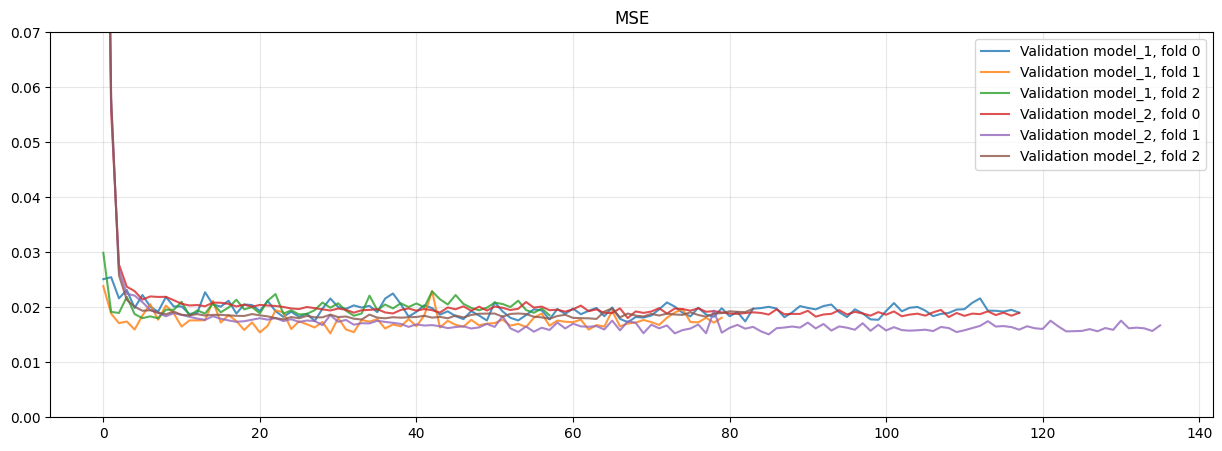

In [25]:
plt.figure(figsize=(15,5))
for i, exp in enumerate(experiments):
  for fold in exp.fold_experiments:
    plt.plot(fold.val_loss_values, label = f"Validation {fold.name}, fold {fold.fold_number}", alpha = exp.alpha)
plt.ylim(0, 0.07)
plt.title('MSE')
plt.legend(loc='upper right')
plt.grid(alpha=.3)
plt.show()

In [26]:
for exp in experiments:
  exp.val_mse = mean(list(map(lambda x: x.val_mse, exp.fold_experiments)))
  print(f"Model {exp.name}, MSE {exp.val_mse}")

Model model_1, MSE 0.016993481665849686
Model model_2, MSE 0.017290810123085976


In [27]:
best_exp = list(sorted(experiments, key=lambda x: x.val_mse))[0]

## Model Selection & Final Retraining

The experiment with the lowest mean fold val MSE is selected. The winning architecture is then **retrained from scratch** on a fresh train/val split carved from `X_train_val`. This is the standard two-stage K-Fold pattern:

1. **Cross-validation** — selects the best hyperparameter configuration (learning rate in this case).
2. **Final retrain** — trains the winning architecture on more data to produce the model evaluated on the test set.

The held-out test set remains untouched until the very final evaluation step.

In [28]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size = len(X_test),
    random_state=SEED, stratify=y_train_val
)

In [29]:
batch_size = 32

train_dataset = data_utils.TensorDataset(
    torch.tensor(X_train.values, dtype = torch.float32), 
    torch.tensor(y_train.values, dtype = torch.float32)
)
trainloader = data_utils.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = data_utils.TensorDataset(
    torch.tensor(X_val.values, dtype = torch.float32), 
    torch.tensor(y_val.values, dtype = torch.float32)
)
valloader = data_utils.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [30]:
best_exp.valloader = valloader
best_exp.trainloader = trainloader

In [31]:
train_experiment(best_exp)

Epoca: 0 |  Train Loss: 0.04535626620054245 | Val Loss: 0.02582784928381443 
Epoca: 1 |  Train Loss: 0.018815789371728897 | Val Loss: 0.02260894887149334 
Epoca: 2 |  Train Loss: 0.017379701137542725 | Val Loss: 0.018869956955313683 
Epoca: 3 |  Train Loss: 0.016618575900793076 | Val Loss: 0.021065471693873405 
Epoca: 4 |  Train Loss: 0.014408809132874012 | Val Loss: 0.020356910303235054 
Epoca: 5 |  Train Loss: 0.01392905879765749 | Val Loss: 0.0194254070520401 
Epoca: 6 |  Train Loss: 0.014025199227035046 | Val Loss: 0.021216459572315216 
Epoca: 7 |  Train Loss: 0.01340117771178484 | Val Loss: 0.022664625197649002 
Epoca: 8 |  Train Loss: 0.012465106323361397 | Val Loss: 0.017566068097949028 
Epoca: 9 |  Train Loss: 0.013547690585255623 | Val Loss: 0.023062966763973236 
Epoca: 10 |  Train Loss: 0.01283031515777111 | Val Loss: 0.021080676466226578 
Epoca: 11 |  Train Loss: 0.01185013260692358 | Val Loss: 0.021551422774791718 
Epoca: 12 |  Train Loss: 0.011627492494881153 | Val Loss: 0

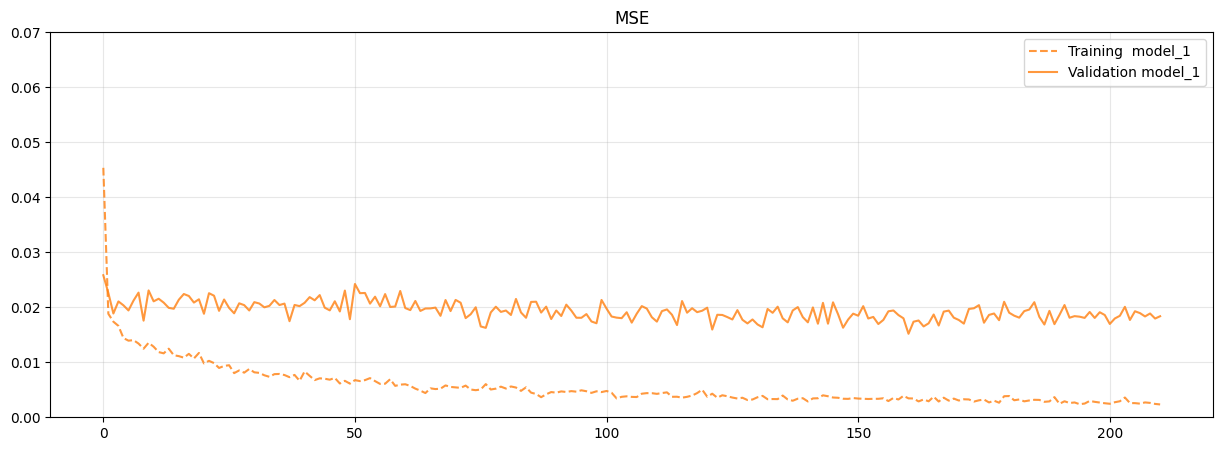

In [32]:
plt.figure(figsize=(15,5))
plt.plot(best_exp.train_loss_values, label=f'Training  {best_exp.name}',  linestyle = '--', color=exp.color, alpha = exp.alpha)
plt.plot(best_exp.val_loss_values, label = f"Validation {best_exp.name}", color=exp.color, alpha = exp.alpha)
plt.ylim(0, 0.07)
plt.title('MSE')
plt.legend(loc='upper right')
plt.grid(alpha=.3)
plt.show()

## Final Evaluation

The retrained best model is evaluated on the held-out test set. Metrics are in the normalized space (MSE on the [0, 1] scale) since this notebook does not denormalize predictions.

> To compare with the student notebook's denormalized results, multiply the normalized MSE by `(max_t - min_t)²` to recover the original-scale MSE, then take the square root for RMSE.

In [33]:
testloader = data_utils.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [34]:
test_mse = test_experiment(best_exp, testloader)
print(f"Best model {best_exp.name}, test MSE: {test_mse}")

Best model model_1, test MSE: 0.02403191477060318
